# ESPRESSO Data Tutorial

This tutorial demonstrates how to create and use RVData standard files for the Echelle SPectrograph for Rocky Exoplanets and Stable Spectroscopic Observations (ESPRESSO) instrument at all data levels:

- **Level 2 (L2)**: Extracted, wavelength-calibrated echelle spectra
- **Level 3 (L3)**: Stitched 1D spectrum on a common wavelength grid
- **Level 4 (L4)**: Radial velocity measurements

## Prerequisites

Install the rvdata package:
```bash
pip install rv-data-standard
```

## Setup and Data Download

First, we'll import the necessary modules and download sample ESPRESSO data files.

In [4]:
import os
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits

# RVData imports
from rvdata.core.models.level2 import RV2
from rvdata.core.models.level3 import RV3
from rvdata.core.models.level4 import RV4

def download_file(url, filename):
    """Download a file if it doesn't already exist."""
    if not os.path.exists(filename):
        print(f"Downloading {filename}...")
        response = requests.get(url)
        response.raise_for_status()
        with open(filename, "wb") as f:
            f.write(response.content)
        print(f"Downloaded {filename}")
    else:
        print(f"{filename} already exists, skipping download.")

# ESPRESSO sample data URLs (hosted on project server)

file_urls = {
     "raw": "http://grinnell.as.arizona.edu/~rvdata/espresso/ESPRE.2017-12-03T02-09-40.348.fits",
        "S2D_BLAZE_A": "http://grinnell.as.arizona.edu/~rvdata/espresso/r.ESPRE.2017-12-03T02-09-40.348_S2D_BLAZE_A.fits",
        "S2D_BLAZE_B": "http://grinnell.as.arizona.edu/~rvdata/espresso/r.ESPRE.2017-12-03T02-09-40.348_S2D_BLAZE_B.fits",
        "BLAZE_A": "http://grinnell.as.arizona.edu/~rvdata/espresso/r.ESPRE.2017-12-03T10-43-59.835_BLAZE_A.fits",
        "BLAZE_B": "http://grinnell.as.arizona.edu/~rvdata/espresso/r.ESPRE.2017-12-03T10-43-59.835_BLAZE_B.fits",
        "S1D_A": "http://grinnell.as.arizona.edu/~rvdata/espresso/r.ESPRE.2017-12-03T02-09-40.348_S1D_A.fits",
        "S1D_B": "http://grinnell.as.arizona.edu/~rvdata/espresso/r.ESPRE.2017-12-03T02-09-40.348_S1D_B.fits",
        "S1D_TELL_CORR_A": "http://grinnell.as.arizona.edu/~rvdata/espresso/r.ESPRE.2017-12-03T02-09-40.348_S1D_TELL_CORR_A.fits",
        "DRIFT_MATRIX_B": "http://grinnell.as.arizona.edu/~rvdata/espresso/r.ESPRE.2017-12-03T02-09-40.348_DRIFT_MATRIX_B.fits",
        "CCF_A": "http://grinnell.as.arizona.edu/~rvdata/espresso/r.ESPRE.2017-12-03T02-09-40.348_CCF_A.fits",
        "CCF_TELL_CORR_A": "http://grinnell.as.arizona.edu/~rvdata/espresso/r.ESPRE.2017-12-03T02-09-40.348_CCF_TELL_CORR_A.fits"
}

# Download the files
raw_file = "ESPRE.2017-12-03T02:09:40.348.fits"
s2d_blaze_A = "r.ESPRE.2017-12-03T02:09:40.348_S2D_BLAZE_A.fits"
s2d_blaze_B = "r.ESPRE.2017-12-03T02:09:40.348_S2D_BLAZE_B.fits"
blaze_A = "r.ESPRE.2017-12-03T10:43:59.835_BLAZE_A.fits"
blaze_B = "r.ESPRE.2017-12-03T10:43:59.835_BLAZE_B.fits"
s1d_A = "r.ESPRE.2017-12-03T02:09:40.348_S1D_A.fits"
s1d_B = "r.ESPRE.2017-12-03T02:09:40.348_S1D_B.fits"
s1d_tel_corr_A = "r.ESPRE.2017-12-03T02:09:40.348_S1D_TELL_CORR_A.fits"
drift_matrix = "r.ESPRE.2017-12-03T02:09:40.348_DRIFT_MATRIX_B.fits"
CCF_A = "r.ESPRE.2017-12-03T02:09:40.348_CCF_A.fits"
CCF_TELL_CORRA = "r.ESPRE.2017-12-03T02:09:40.348_CCF_TELL_CORR_A.fits"


download_file(file_urls["raw"], raw_file)
download_file(file_urls["S2D_BLAZE_A"], s2d_blaze_A)
download_file(file_urls["S2D_BLAZE_B"], s2d_blaze_B)
download_file(file_urls["BLAZE_A"], blaze_A)
download_file(file_urls["BLAZE_B"], blaze_B)
download_file(file_urls["S1D_A"], s1d_A)
download_file(file_urls["S1D_B"], s1d_B)
download_file(file_urls["S1D_TELL_CORR_A"], s1d_tel_corr_A)
download_file(file_urls["DRIFT_MATRIX_B"], drift_matrix)
download_file(file_urls["CCF_A"], CCF_A)
download_file(file_urls["CCF_TELL_CORR_A"], CCF_TELL_CORRA)



ESPRE.2017-12-03T02:09:40.348.fits already exists, skipping download.
r.ESPRE.2017-12-03T02:09:40.348_S2D_BLAZE_A.fits already exists, skipping download.
r.ESPRE.2017-12-03T02:09:40.348_S2D_BLAZE_B.fits already exists, skipping download.
r.ESPRE.2017-12-03T10:43:59.835_BLAZE_A.fits already exists, skipping download.
r.ESPRE.2017-12-03T10:43:59.835_BLAZE_B.fits already exists, skipping download.
r.ESPRE.2017-12-03T02:09:40.348_S1D_A.fits already exists, skipping download.
r.ESPRE.2017-12-03T02:09:40.348_S1D_B.fits already exists, skipping download.
r.ESPRE.2017-12-03T02:09:40.348_S1D_TELL_CORR_A.fits already exists, skipping download.
r.ESPRE.2017-12-03T02:09:40.348_DRIFT_MATRIX_B.fits already exists, skipping download.
r.ESPRE.2017-12-03T02:09:40.348_CCF_A.fits already exists, skipping download.
r.ESPRE.2017-12-03T02:09:40.348_CCF_TELL_CORR_A.fits already exists, skipping download.


---
# Level 2: Extracted Echelle Spectra

Level 2 data contains wavelength-calibrated, extracted echelle spectra organized by trace (fiber). Each trace contains flux, wavelength, variance, and blaze function arrays.

## Creating L2 from Native ESPRESSO Files

To create an RVData-standard L2 file from native ESPRESSO data, you need:
- **raw file**: Raw data with headers 
- **S2D files**: Extracted spectra for both fibers from the ESPRESSO pipeline
- **Blaze files** Blaze spectra for both fibers
- **DRIFT file** The measured drift

In [5]:
# Create RVData-standard L2 from native ESPRESSO files
espr_l2 = RV2.from_fits(raw_file, instrument='ESPRESSO')

# Save to FITS file
l2_standard_file = "ESPR_L2_standard.fits"
espr_l2.to_fits(out_filedir=None, out_filename=l2_standard_file)
print(f"Created {l2_standard_file}")

SCIENCE FP HD 10700
File is valid for conversion!
No PS1 data found, PUPILIMAGE extension will not be generated
No TELLURIC file found, TRACEi_TELLURIC_x extensions will not be generated.
No SKYSUB file found, TRACEi_SKYSUB_x extensions will not be generated.
Created ESPR_L2_standard.fits


/Users/emilio/Desktop/EPRV/Translators/RVData/rvdata/core/models/base.py:474: UserWarning: Filename 'ESPR_L2_standard.fits' does not follow the EPRV naming convention. Suggested filename: 'espresso_SL2_20171203T020940.fits'
  warnings.warn(


## Using L2 Data

### Reading the L2 File

You can read L2 files using either astropy's `fits.open()` or the RVData `RV2.from_fits()` method.

In [6]:
# Open using astropy
l2 = fits.open(l2_standard_file)

# Examine the primary header - same keywords regardless of instrument!
hdr = l2[0].header
print(f"Telescope: {hdr['TELESCOP']}")
print(f"Instrument: {hdr['INSTRUME']}")
print(f"Object: {hdr['OBJECT']}")
print(f"Number of traces: {hdr['NUMTRACE']}")
print("\nTrace contents:")
for i in range(1, hdr['NUMTRACE'] + 1):
    print(f"  TRACE{i}: {hdr[f'TRACE{i}']}")

Telescope: ESO-VLT-U1
Instrument: ESPRESSO
Object: HD 10700
Number of traces: 4

Trace contents:
  TRACE1: SCI
  TRACE2: SCI
  TRACE3: CAL
  TRACE4: CAL


### Examining L2 Extensions

The `EXT_DESCRIPT` extension lists all FITS extensions in the file.

In [7]:
# List all extensions
ext_descript = pd.DataFrame(l2['EXT_DESCRIPT'].data)
print(ext_descript[['Name', 'Description']].to_string())

                 Name                                                               Description
0             PRIMARY  The primary header containing the keywords following the standard format
1   INSTRUMENT_HEADER                                            The original instrument header
2             RECEIPT                             The list of operations performed on this file
3          DRP_CONFIG                     Pipeline details to go from the raw file to this file
4        EXT_DESCRIPT                Contains the description of all the extensions in the file
5         ORDER_TABLE                       Table capturing the wavelength extent of each order
6         TRACE1_FLUX                                              The flux measured in trace 1
7         TRACE1_WAVE                          The wavelength associated to the flux in trace 1
8          TRACE1_VAR                                                  The variance for trace 1
9        TRACE1_BLAZE                   

### Examining the Order Table

The `ORDER_TABLE` extension describes the wavelength coverage of each echelle order.

In [8]:
order_table = pd.DataFrame(l2['ORDER_TABLE'].data)
print(f"Number of orders: {len(order_table)}")
print(f"\nWavelength coverage: {order_table['WAVE_START'].min():.1f} - {order_table['WAVE_END'].max():.1f} Angstroms")
print("\nFirst 5 orders:")
print(order_table.head())

Number of orders: 85

Wavelength coverage: 377.1 - 790.6 Angstroms

First 5 orders:
   ETC/Int_Order HR/UHR_Orders  MR_Order  Central_wav[nm]  FSR_range[nm]  \
0            161           1,2         1           380.04           2.36   
1            160           3,4         2           382.42           2.39   
2            159           5,6         3           384.83           2.42   
3            158           7,8         4           387.26           2.45   
4            157          9,10         5           389.73           2.48   

   FSRmin[nm]  FSRmax[nm]  start_wav[nm]  endwav[nm]  TS_range[nm]  \
0      378.87      381.23         377.15      383.07          5.93   
1      381.23      383.62         379.50      385.47          5.96   
2      383.62      386.04         381.89      387.89          6.00   
3      386.04      388.49         384.31      390.34          6.03   
4      388.49      390.97         386.76      392.83          6.07   

   ECHELLE_ORDER  ORDER_INDEX  WAVE_ST

### Plotting L2 Spectra

ESPRESSO has 4 traces:
- TRACE 1 and 2: Science fibers, slices 1 & 2
- TRACE 3 and 4: Calibration fiber, slices 1 & 2


Let's plot one order from all traces.

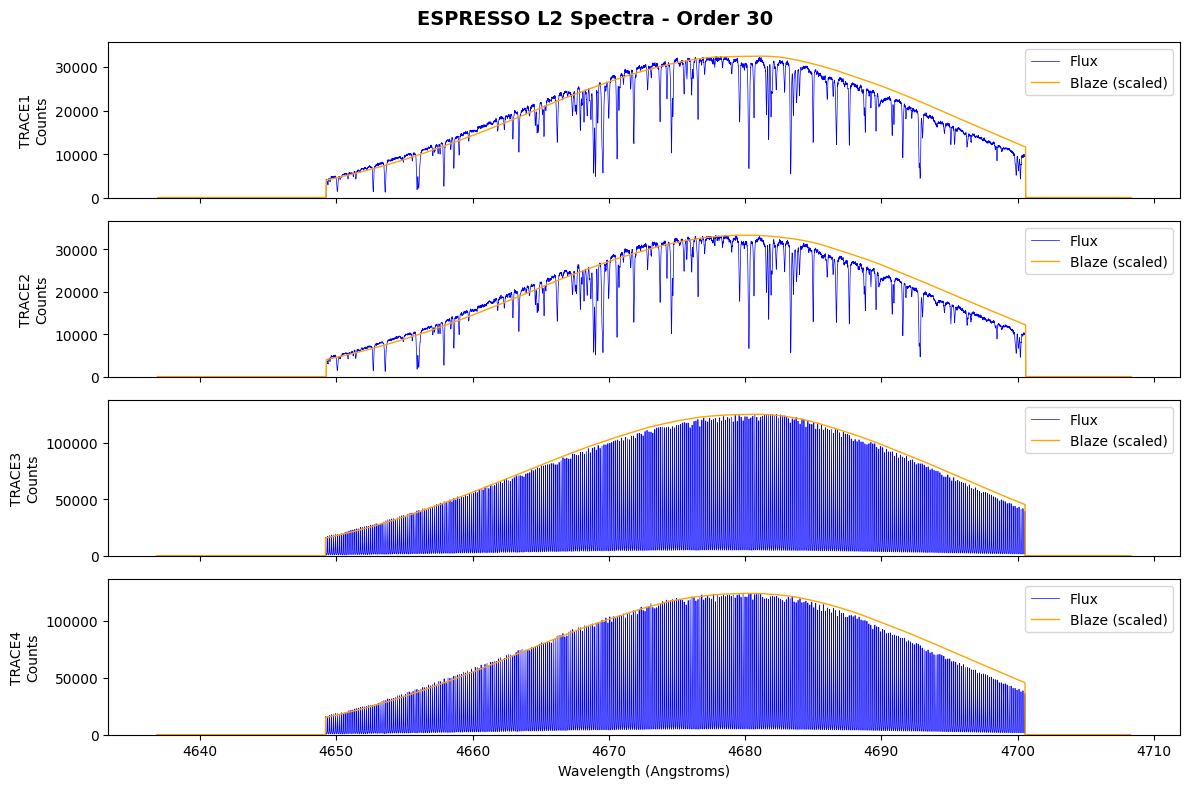

In [9]:
# Plot a single order from the three science traces
order = 30  # Choose an order to plot

fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)

for i, (ax, trace_num) in enumerate(zip(axes, [1,2, 3, 4])):
    wave = l2[f'TRACE{trace_num}_WAVE'].data[order]
    flux = l2[f'TRACE{trace_num}_FLUX'].data[order]
    blaze = l2[f'TRACE{trace_num}_BLAZE'].data[order]
    
    # Scale blaze for visualization
    blaze_scaled = blaze * (np.nanmax(flux) / np.nanmax(blaze))
    
    ax.plot(wave, flux, 'b-', lw=0.5, label='Flux')
    ax.plot(wave, blaze_scaled, 'orange', lw=1, label='Blaze (scaled)')
    ax.set_ylabel(f'TRACE{trace_num}\nCounts')
    ax.legend(loc='upper right')
    ax.set_ylim(0, np.nanmax(flux) * 1.1)

axes[-1].set_xlabel('Wavelength (Angstroms)')
fig.suptitle(f'ESPRESSO L2 Spectra - Order {order}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
# Level 3: Stitched 1D Spectrum

Level 3 data contains a stitched 1D spectrum on a common wavelength grid with constant velocity spacing. The stitching process:
1. Divides out the blaze function
2. Resamples each order onto a common wavelength grid

ESPRESSO level 3 files are obtained from S1D files produced by the ESPRESSO DRS.

In [10]:
# Create L3 from the standard L2 file
espr_l3 = RV3.from_fits(raw_file, instrument="ESPRESSO")

# Save to FITS file
l3_standard_file = "ESPR_L3_standard.fits"
espr_l3.to_fits(out_filedir=None, out_filename=l3_standard_file)
print(f"Created {l3_standard_file}")

SCIENCE FP HD 10700
File r.ESPRE.2017-12-03T02:09:40.348_S1D_SKYSUB_A.fits does not exist.
Created ESPR_L3_standard.fits


/Users/emilio/Desktop/EPRV/Translators/RVData/rvdata/core/models/base.py:474: UserWarning: Filename 'ESPR_L3_standard.fits' does not follow the EPRV naming convention. Suggested filename: 'espresso_SL3_20171203T020940.fits'
  warnings.warn(


## Using L3 Data

### Reading the L3 File

In [11]:
# Open the L3 file
l3 = fits.open(l3_standard_file)

# List extensions
print("L3 Extensions:")
for hdu in l3:
    print(f"  {hdu.name}")

L3 Extensions:
  PRIMARY
  INSTRUMENT_HEADER
  RECEIPT
  DRP_CONFIG
  EXT_DESCRIPT
  ORDER_TABLE
  STITCHED_CORR_SCI_FLUX
  STITCHED_CORR_SCI_WAVE
  STITCHED_CORR_SCI_VAR
  STITCHED_TELLCORR_SCI_WAVE
  STITCHED_TELLCORR_SCI_FLUX
  STITCHED_TELLCORR_SCI_VAR


### Understanding L3 Extensions

For ESPRESSO with a single science fiber, the stitched spectrum is stored in `STITCHED_CORR_SCI_*` extensions:
- `STITCHED_CORR_SCI_WAVE/FLUX/VAR`

In [12]:
# Check which STITCHED extensions are present
stitched_exts = [hdu.name for hdu in l3 if 'STITCHED' in hdu.name]
print("Stitched spectrum extensions:")
for ext in stitched_exts:
    print(f"  {ext}")

Stitched spectrum extensions:
  STITCHED_CORR_SCI_FLUX
  STITCHED_CORR_SCI_WAVE
  STITCHED_CORR_SCI_VAR
  STITCHED_TELLCORR_SCI_WAVE
  STITCHED_TELLCORR_SCI_FLUX
  STITCHED_TELLCORR_SCI_VAR


### Plotting the Stitched Spectrum

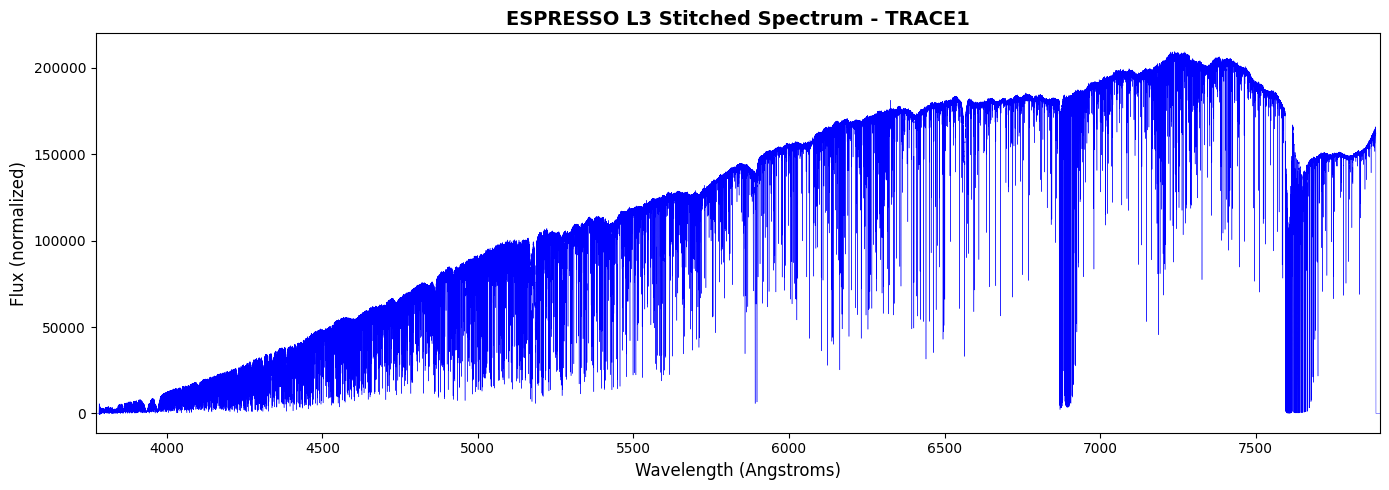


Wavelength range: 3772.0 - 7900.0 Angstroms
Number of pixels: 443262


In [13]:
# Plot the stitched spectrum for one trace
# Check which trace extensions exist
trace_num = 1  # Try TRACE2 first
wave_ext = f'STITCHED_CORR_SCI_WAVE'
flux_ext = f'STITCHED_CORR_SCI_FLUX'

if wave_ext in [hdu.name for hdu in l3]:
    wave_l3 = l3[wave_ext].data
    flux_l3 = l3[flux_ext].data
    
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(wave_l3, flux_l3, 'b-', lw=0.3)
    ax.set_xlabel('Wavelength (Angstroms)', fontsize=12)
    ax.set_ylabel('Flux (normalized)', fontsize=12)
    ax.set_title(f'ESPRESSO L3 Stitched Spectrum - TRACE{trace_num}', fontsize=14, fontweight='bold')
    
    # Zoom inset
    ax.set_xlim(wave_l3[np.isfinite(wave_l3)].min(), wave_l3[np.isfinite(wave_l3)].max())
    plt.tight_layout()
    plt.show()
    
    print(f"\nWavelength range: {np.nanmin(wave_l3):.1f} - {np.nanmax(wave_l3):.1f} Angstroms")
    print(f"Number of pixels: {len(wave_l3)}")
else:
    print(f"Extension {wave_ext} not found. Available: {stitched_exts}")

### Zoomed View of Spectral Features

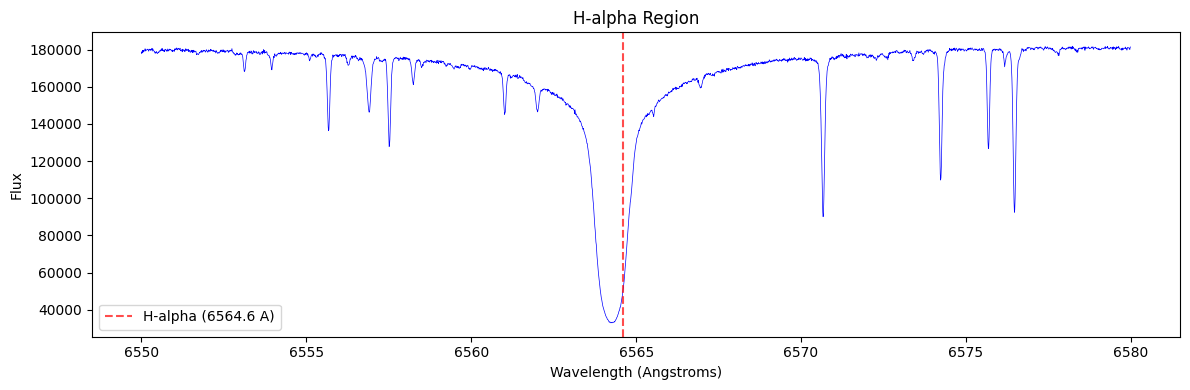

In [14]:
# Zoom in on H-alpha region
if wave_ext in [hdu.name for hdu in l3]:
    fig, ax = plt.subplots(figsize=(12, 4))
    
    # H-alpha region
    mask = (wave_l3 > 6550) & (wave_l3 < 6580)
    ax.plot(wave_l3[mask], flux_l3[mask], 'b-', lw=0.5)
    ax.axvline(6564.6, color='red', ls='--', alpha=0.7, label='H-alpha (6564.6 A)')
    ax.set_xlabel('Wavelength (Angstroms)')
    ax.set_ylabel('Flux')
    ax.set_title('H-alpha Region', fontsize=12)
    ax.legend()
    plt.tight_layout()
    plt.show()

---
# Level 4: Radial Velocity Measurements

Level 4 data contains radial velocity (RV) measurements derived from the spectra. These can include:
- Per-order RVs
- Combined RV with uncertainty
- Activity indicators

## Creating L4 from ESPRESSO CCF data

L4 is typically created from native pipeline outputs that contain RV measurements. For ESPRESSO, the native CCF file includes CCF-derived RVs.

In [15]:
# Create L4 from native ESPRESSO CCF file (which contains RV measurements)
espr_l4 = RV4.from_fits(raw_file, instrument="ESPRESSO")

# Save to FITS file
l4_standard_file = "espr_L4_standard.fits"
espr_l4.to_fits(out_filedir=None, out_filename=l4_standard_file)
print(f"Created {l4_standard_file}")

SCIENCE FP HD 10700
File r.ESPRE.2017-12-03T02:09:40.348_CCF_SKYSUB_A.fits not found. Skipping...
Created espr_L4_standard.fits


/Users/emilio/Desktop/EPRV/Translators/RVData/rvdata/core/models/base.py:474: UserWarning: Filename 'espr_L4_standard.fits' does not follow the EPRV naming convention. Suggested filename: 'espresso_SL4_20171203T020940.fits'
  warnings.warn(


## Using L4 Data

### Reading the L4 File

In [16]:
# Open the L4 file
l4 = fits.open(l4_standard_file)

# Examine primary header for RV info
hdr4 = l4[0].header
print(f"Object: {hdr4['OBJECT']}")
print(f"Observation time (BJD): {hdr4.get('BJDTDB', 'N/A')}")

# List extensions
print("\nL4 Extensions:")
for hdu in l4:
    print(f"  {hdu.name}")

Object: HD 10700
Observation time (BJD): 2458090.59436763

L4 Extensions:
  PRIMARY
  INSTRUMENT_HEADER
  RECEIPT
  DRP_CONFIG
  EXT_DESCRIPT
  RV1
  CCF1
  DIAGNOSTICS1
  RV_TEL_CORR
  CCF_TEL_CORR


### Examining the RV1 Extension

The `RV1` extension contains per-order radial velocity measurements with standardized column names.

In [17]:
# Examine the RV1 extension
rv1 = pd.DataFrame(l4['RV1'].data)
print("RV1 columns:")
print(rv1.columns.tolist())
print(f"\nNumber of orders: {len(rv1)}")
print("\nFirst 5 rows:")
print(rv1.head())

RV1 columns:
['BJD_TDB', 'RV', 'RV_ERR', 'BERV', 'WAVE_START', 'WAVE_END']

Number of orders: 1

First 5 rows:
        BJD_TDB         RV    RV_ERR       BERV  WAVE_START  WAVE_END
0  2.458091e+06 -15.082474  0.000205 -22.110426         NaN       NaN


---
# Summary

This tutorial demonstrated how to:

1. **Create L2** from native ESPRESSO files using `RV2.from_fits()`
2. **Use L2** data: access headers, examine extensions, plot spectra
3. **Create L3** from native ESPRESSO files using `RV3.from_fits()`
4. **Use L3** data: access stitched spectra, examine spectral features
5. **Create L4** from native ESPRESSO files using `RV4.from_fits()`
6. **Use L4** data: access RV measurements and per-order RVs

The standardized data format allows consistent access patterns across all EPRV instruments!

In [18]:
# Clean up - close FITS files
l2.close()
l3.close()
l4.close()